<a href="https://colab.research.google.com/github/duytuethinghiep/ueh_investments2/blob/main/lab01_phan_tich_kham_pha_du_lieu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cài đặt lib

In [ ]:
!pip install ydata_profiling
!pip install sweetviz
!pip install AutoViz
!pip install dtale


!wget -O "data.zip" "https://drive.google.com/uc?export=download&id=1fOFKzMnQv-udo0pHn1N7FzzKiF0Uifoh" && unzip "data.zip"
import pandas as pd  #for data manipulation operations
import numpy as np  #for numeric operations on data
import seaborn as sns  #for data visualization operations
import matplotlib.pyplot as plt  #for data visualization operations
from scipy import stats  #for statistical operations
from ydata_profiling import ProfileReport
import dtale

marketing = pd.read_csv("customer-personality-analysis.csv")
online_retail = pd.read_excel("eda-online-retail.xlsx")
diabetes = pd.read_csv("pima-indians-diabetes-eda-prediction-0-906.csv")
wine = pd.read_csv("red-wine-quality-eda-classification.csv")

--2026-05-17 13:18:11--  https://drive.google.com/uc?export=download&id=1fOFKzMnQv-udo0pHn1N7FzzKiF0Uifoh
Resolving drive.google.com (drive.google.com)... 173.194.174.102, 173.194.174.101, 173.194.174.113, ...
Connecting to drive.google.com (drive.google.com)|173.194.174.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1fOFKzMnQv-udo0pHn1N7FzzKiF0Uifoh&export=download [following]
--2026-05-17 13:18:12--  https://drive.usercontent.google.com/download?id=1fOFKzMnQv-udo0pHn1N7FzzKiF0Uifoh&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.204.132, 2404:6800:4008:c04::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.204.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22971753 (22M) [application/octet-stream]
Saving to: ‘data.zip’

data.zip            100%[===================>]  21.91M  47.1MB/s  

# 1.1 THỐNG KÊ MÔ TẢ

## 1.1.1 Ôn tập lý thuyết

**Q1: Thống kê mô tả là gì? Nó khác gì với thống kê suy luận (inferential statistics)?**  
A1: Thống kê mô tả là phương pháp tóm tắt, mô tả và trình bày dữ liệu bằng các chỉ số, bảng, biểu đồ, giúp hiểu nhanh cấu trúc dữ liệu. Thống kê suy luận dùng mẫu để suy luận về tổng thể, áp dụng kiểm định giả thuyết, ước lượng tham số hoặc hồi quy.

---

**Q2: Các thước đo thống kê mô tả chính (ví dụ: trung bình, trung vị, phương sai, độ lệch chuẩn) được sử dụng để làm gì? Trong trường hợp nào thì nên dùng trung vị thay vì trung bình?**  
A2:  
- Trung bình: đo giá trị trung tâm, dùng khi dữ liệu phân bố chuẩn, không có outlier.  
- Trung vị: đo giá trị ở giữa, dùng khi dữ liệu lệch hoặc có outlier.  
- Phương sai, độ lệch chuẩn: đo mức độ phân tán quanh trung bình.  
- Min/Max, Range: đo phạm vi trải rộng dữ liệu.  
- Q1, Q3: đánh giá phân bố và outlier.  

---

**Q3: Làm thế nào để xác định phân bố của một tập dữ liệu? Các loại phân bố phổ biến là gì (ví dụ: phân bố chuẩn, lệch trái, lệch phải)?**  
A3: Quan sát histogram, boxplot hoặc dùng kiểm định thống kê (Shapiro-Wilk, Kolmogorov-Smirnov). Các phân bố phổ biến: chuẩn, lệch trái, lệch phải, đồng đều.

---

**Q4: Độ lệch chuẩn và phạm vi (range) có ý nghĩa gì trong việc đánh giá sự phân tán của dữ liệu?**  
A4:  
- Độ lệch chuẩn: đo mức độ dữ liệu phân tán quanh trung bình; giá trị lớn → phân tán nhiều.  
- Phạm vi: khoảng cách giữa giá trị cực đại và cực tiểu, cho thấy mức trải rộng dữ liệu.

---

**Q5: Sự khác biệt giữa các thước đo như Q1, Q2, Q3 trong biểu đồ hộp (boxplot) là gì?**  
A5:  
- Q1 (25%): 25% dữ liệu nhỏ hơn hoặc bằng Q1.  
- Q2 (50%) = Median: 50% dữ liệu nhỏ hơn hoặc bằng Q2.  
- Q3 (75%): 75% dữ liệu nhỏ hơn hoặc bằng Q3.  
- IQR = Q3 - Q1, dùng để xác định outlier.

---

**Q6: Làm thế nào để xử lý giá trị thiếu (missing values) trước khi tính toán các chỉ số thống kê mô tả?**  
A6: Có thể:  
- Loại bỏ bản ghi chứa giá trị thiếu.  
- Thay bằng trung bình, trung vị hoặc dự đoán giá trị.  
- Chọn phương pháp tùy thuộc vào loại dữ liệu và mục tiêu phân tích.

---

**Q7: Bạn có thể giải thích cách đọc và diễn giải một biểu đồ histogram hoặc boxplot từ dữ liệu thực tế không?**  
A7:  
- Histogram: quan sát tần suất xuất hiện của giá trị, hình dạng phân bố, lệch trái/phải, nhiều đỉnh.  
- Boxplot: quan sát phân vị, giá trị ngoại lai, độ lệch và so sánh nhiều nhóm dữ liệu.

---

**Q8: Khi gặp một tập dữ liệu có giá trị ngoại lai (outliers), bạn sẽ xử lý chúng như thế nào trước khi thực hiện thống kê mô tả?**  
A8:  
- Nhận biết outlier: dữ liệu nằm ngoài Q1 - 1.5*IQR hoặc Q3 + 1.5*IQR.  
- Xử lý:  
  - Loại bỏ nếu là lỗi đo lường.  
  - Giữ lại nếu phản ánh hiện thực.  
  - Biến đổi dữ liệu (log, sqrt) để giảm ảnh hưởng.

## 1.1.3. Bài tập thực hành 1

+ Thực hiện thống kê mô tả trên tập dữ liệu về phân loại chất lượng rượu đỏ.
Dữ liệu lấy tại https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification

In [ ]:
def analyze(df):
    for col in df.columns:
        if np.issubdtype(df[col].dtype, np.number):

            print(f"""
Column: {col}

Mean: {np.mean(df[col])}
Median: {np.median(df[col])}
Mode: {stats.mode(df[col], keepdims=True).mode[0]}
Variance: {np.var(df[col])}
Std Dev: {np.std(df[col])}
Max: {np.max(df[col])}
Min: {np.min(df[col])}
60th Percentile: {np.percentile(df[col], 60)}
75th Percentile: {np.percentile(df[col], 75)}
Range: {np.max(df[col]) - np.min(df[col])}
IQR: {stats.iqr(df[col])}
Skewness: {stats.skew(df[col])}
Kurtosis: {stats.kurtosis(df[col])}

-----------------------------------
""")

    print("\n===== df.describe().T (CHECK) =====")
    display(df.describe().T.style.background_gradient(cmap = "magma"))


In [ ]:
print("\n===== wine =====")
analyze(wine)


===== wine =====

Column: fixed acidity

Mean: 8.31963727329581
Median: 7.9
Mode: 7.2
Variance: 3.0295205688671296
Std Dev: 1.7405518001102782
Max: 15.9
Min: 4.6
60th Percentile: 8.3
75th Percentile: 9.2
Range: 11.3
IQR: 2.0999999999999996
Skewness: 0.9818292953262073
Kurtosis: 1.1248563352037486

-----------------------------------


Column: volatile acidity

Mean: 0.5278205128205128
Median: 0.52
Mode: 0.6
Variance: 0.03204232613332036
Std Dev: 0.17900370424468975
Max: 1.58
Min: 0.12
60th Percentile: 0.57
75th Percentile: 0.64
Range: 1.46
IQR: 0.25
Skewness: 0.6709623963499574
Kurtosis: 1.2179633893005306

-----------------------------------


Column: citric acid

Mean: 0.2709756097560976
Median: 0.26
Mode: 0.0
Variance: 0.037923751124940605
Std Dev: 0.1947402144523329
Max: 1.0
Min: 0.0
60th Percentile: 0.32
75th Percentile: 0.42
Range: 1.0
IQR: 0.32999999999999996
Skewness: 0.3180385895475358
Kurtosis: -0.7902825153036646

-----------------------------------


Column: residual sugar

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.000000,8.319637,1.741096,4.600000,7.100000,7.900000,9.200000,15.900000
volatile acidity,1599.000000,0.527821,0.179060,0.120000,0.390000,0.520000,0.640000,1.580000
citric acid,1599.000000,0.270976,0.194801,0.000000,0.090000,0.260000,0.420000,1.000000
residual sugar,1599.000000,2.538806,1.409928,0.900000,1.900000,2.200000,2.600000,15.500000
chlorides,1599.000000,0.087467,0.047065,0.012000,0.070000,0.079000,0.090000,0.611000
free sulfur dioxide,1599.000000,15.874922,10.460157,1.000000,7.000000,14.000000,21.000000,72.000000
total sulfur dioxide,1599.000000,46.467792,32.895324,6.000000,22.000000,38.000000,62.000000,289.000000
density,1599.000000,0.996747,0.001887,0.990070,0.995600,0.996750,0.997835,1.003690
pH,1599.000000,3.311113,0.154386,2.740000,3.210000,3.310000,3.400000,4.010000
sulphates,1599.000000,0.658149,0.169507,0.330000,0.550000,0.620000,0.730000,2.000000


## 1.1.4. Bài tập thực hành 2

+ Thực hiện thống kê mô tả trên tập dữ liệu về bệnh tiểu đường. Dữ liệu lấy tại
https://www.kaggle.com/code/vincentlugat/pima-indians-diabetes-eda-prediction-0-906

In [ ]:
print("\n===== diabetes =====")
analyze(diabetes)


===== diabetes =====

Column: Pregnancies

Mean: 3.8450520833333335
Median: 3.0
Mode: 1
Variance: 11.33927239312061
Std Dev: 3.3673836124089886
Max: 17
Min: 0
60th Percentile: 4.0
75th Percentile: 6.0
Range: 17
IQR: 5.0
Skewness: 0.8999119408414357
Kurtosis: 0.15038273760948462

-----------------------------------


Column: Glucose

Mean: 120.89453125
Median: 117.0
Mode: 99
Variance: 1020.9172617594401
Std Dev: 31.95179590820272
Max: 199
Min: 0
60th Percentile: 125.0
75th Percentile: 140.25
Range: 199
IQR: 41.25
Skewness: 0.17341395519987735
Kurtosis: 0.6288133337300685

-----------------------------------


Column: BloodPressure

Mean: 69.10546875
Median: 72.0
Mode: 70
Variance: 374.1594492594401
Std Dev: 19.343201628981696
Max: 122
Min: 0
60th Percentile: 74.0
75th Percentile: 80.0
Range: 122
IQR: 18.0
Skewness: -1.8400052311728738
Kurtosis: 5.138690662525438

-----------------------------------


Column: SkinThickness

Mean: 20.536458333333332
Median: 23.0
Mode: 0
Variance: 254.141

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


# 1.2 XỬ LÝ VÀ TRỰC QUAN HÓA DỮ LIỆU

## 1.2.1 Ôn tập lý thuyết

**Q1: Trực quan hóa dữ liệu có vai trò gì trong phân tích dữ liệu? Tại sao nó quan trọng trong khám phá dữ liệu (EDA)?**  
A1: Trực quan hóa dữ liệu giúp hiểu nhanh cấu trúc và mối quan hệ trong dữ liệu, nhận biết xu hướng, mẫu, bất thường, outlier, phân bố và tương quan giữa các biến. Trong EDA, trực quan hóa quan trọng vì nó giúp phát hiện vấn đề tiềm ẩn và đưa ra giả thuyết cho phân tích tiếp theo.

---

**Q2: Các loại biểu đồ phổ biến (như histogram, scatter plot, boxplot, bar chart) được sử dụng trong các trường hợp nào?**  
A2:  
- **Histogram**: Phân bố dữ liệu số, tần suất xuất hiện.  
- **Scatter plot**: Mối quan hệ giữa hai biến số.  
- **Boxplot**: Phân bố, trung vị, phân vị, giá trị ngoại lai.  
- **Bar chart**: So sánh giá trị giữa các nhóm phân loại.  

---

**Q3: Làm thế nào để chọn loại biểu đồ phù hợp với đặc điểm của dữ liệu (ví dụ: dữ liệu phân loại, dữ liệu số, dữ liệu thời gian)?**  
A3:  
- Dữ liệu **số (numeric)**: Histogram, boxplot, line plot (nếu theo thời gian).  
- Dữ liệu **phân loại (categorical)**: Bar chart, pie chart.  
- Dữ liệu **thời gian (time series)**: Line plot, area chart.  
- Lưu ý: Chọn biểu đồ phản ánh rõ nhất thông tin cần truyền đạt.

---

**Q4: Sự khác biệt giữa các thư viện trực quan hóa trong Python như Matplotlib, Seaborn và Plotly là gì?**  
A4:  
- **Matplotlib**: Thư viện cơ bản, linh hoạt, vẽ hầu hết loại biểu đồ nhưng cần nhiều code.  
- **Seaborn**: Dựa trên Matplotlib, trực quan đẹp hơn, hỗ trợ thống kê (hue, boxplot, violin, pairplot…).  
- **Plotly**: Biểu đồ tương tác, xuất web dễ dàng, có thể zoom, hover, tooltip, phù hợp báo cáo online.  

---

**Q5: Những nguyên tắc thiết kế nào cần tuân thủ để tạo ra một biểu đồ trực quan hóa dễ hiểu và hiệu quả?**  
A5:  
- Giữ biểu đồ **đơn giản, rõ ràng**, không quá nhiều chi tiết.  
- Có **tiêu đề, trục, nhãn và đơn vị** rõ ràng.  
- Dùng **màu sắc hợp lý**, tránh quá nhiều màu gây rối.  
- Trình bày dữ liệu theo **thứ tự hợp lý**, ví dụ từ nhỏ → lớn.  
- Tránh **hiệu ứng gây hiểu nhầm**, tỉ lệ trục x và y nên hợp lý.  

---

**Q6: Làm thế nào để tạo một biểu đồ đơn giản như histogram hoặc bar chart bằng Matplotlib?**  
A6: Dễ dàng thực hiện bằng các hàm cơ bản của Matplotlib. Cần xác định: dữ liệu, loại biểu đồ, nhãn trục và tiêu đề. (Chi tiết code không yêu cầu ở đây).

---

**Q7: Làm thế nào để xuất biểu đồ từ Python ra các định dạng như PNG, PDF hoặc HTML để sử dụng trong báo cáo?**  
A7:  
- Có thể lưu trực tiếp từ thư viện Matplotlib/Seaborn bằng các hàm xuất file: PNG, JPG, PDF.  
- Với Plotly, biểu đồ có thể xuất sang HTML để duy trì tính tương tác.  
- Luôn đặt tên file và thư mục lưu hợp lý để quản lý báo cáo dễ dàng.  

## 1.2.2. Bài làm mẫu

### 2. Trực quan hóa dữ liệu với thư viện Matplotlib

In [ ]:
import pandas as pd  #for data manipulation operations
import numpy as np  #for numeric operations on data
import seaborn as sns  #for data visualization operations
import matplotlib.pyplot as plt  #for data visualization operations
from scipy import stats  #for statistical operations

houseprices_data = pd.read_csv("https://drive.google.com/uc?id=1R2fD4P0kxm-jupWrhOZbZGrbmLJRpcgG")
houseprices_data.head()
houseprices_data = houseprices_data[['Zip', 'Price', 'Area', 'Room']]

# Create a PriceperSqm variable based on the Price and Area variables:
houseprices_data['PriceperSqm'] = houseprices_data['Price']/houseprices_data['Area']
houseprices_sorted = houseprices_data.sort_values(by=['PriceperSqm'], ascending=False)
houseprices_sorted.head()

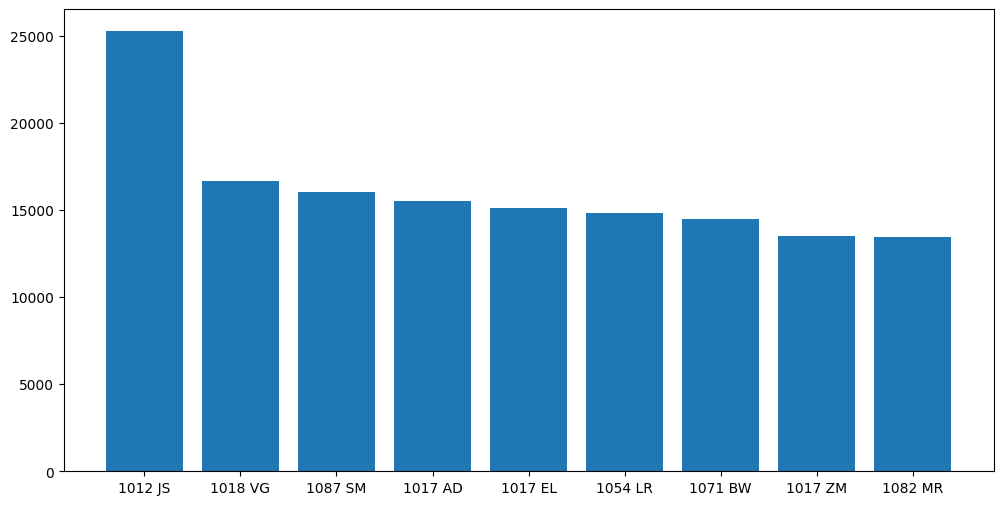

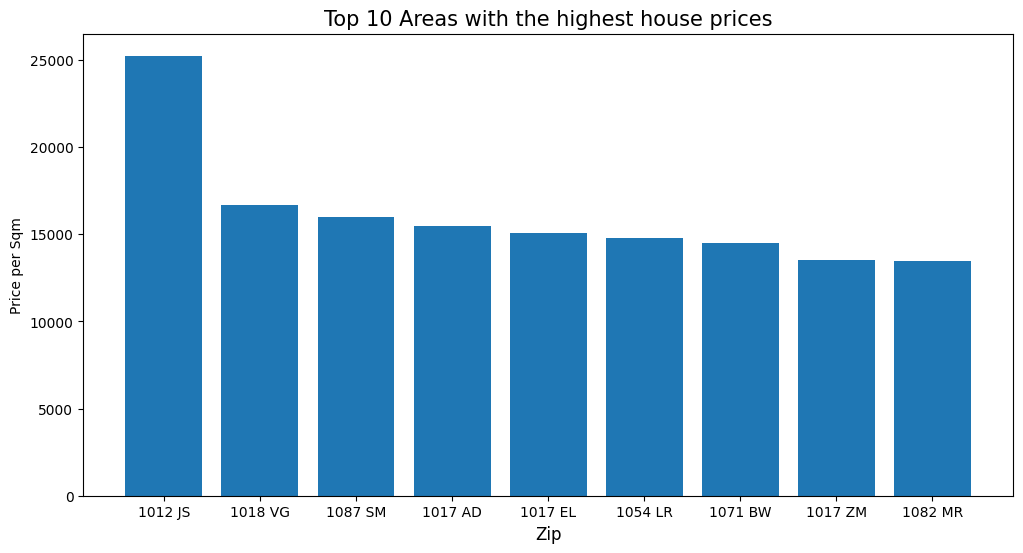

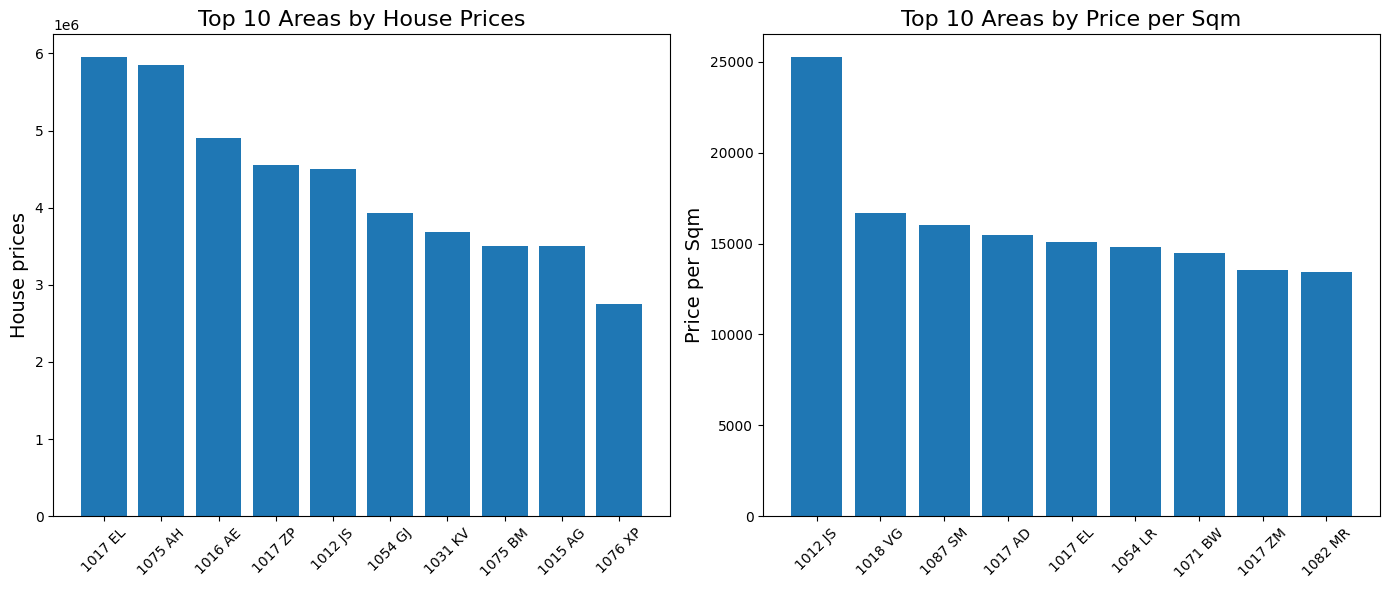

In [ ]:
# case 1: basic
plt.figure(figsize=(12,6))
x = houseprices_sorted['Zip'][0:10]
y = houseprices_sorted['PriceperSqm'][0:10]
plt.bar(x,y)
plt.show()

# case 2: advanced 1
plt.figure(figsize=(12,6))
plt.bar(x,y)
plt.title("Top 10 Areas with the highest house prices", fontsize = 15)
plt.xlabel("Zip", fontsize=12)
plt.xticks(fontsize=10)
plt.ylabel("Price per Sqm")
plt.yticks(fontsize=10)
#plt.tight_layout(rect=[0, 0, 1, 0.8])  # leaves 5% at the top for the title
plt.show()

# case 3: advanced 2
plt.figure(figsize=(14,6))
# Left plot: Top 10 by Price
plt.subplot(1,2,1)
plt.bar(
    houseprices_data.nlargest(10, 'Price')['Zip'],
    houseprices_data.nlargest(10, 'Price')['Price']
)
plt.xticks(rotation=45, fontsize=10)
plt.ylabel("House prices", fontsize=14)
plt.title("Top 10 Areas by House Prices", fontsize=16)
# Right plot: Top 10 by Price per Sqm
plt.subplot(1,2,2)
plt.bar(
    houseprices_data.nlargest(10, 'PriceperSqm')['Zip'],
    houseprices_data.nlargest(10, 'PriceperSqm')['PriceperSqm']
)
plt.xticks(rotation=45, fontsize=10)
plt.ylabel("Price per Sqm", fontsize=14)
plt.title("Top 10 Areas by Price per Sqm", fontsize=16)

plt.tight_layout()
plt.show()

### 3. Trực quan hóa dữ liệu với thư viện Seaborn

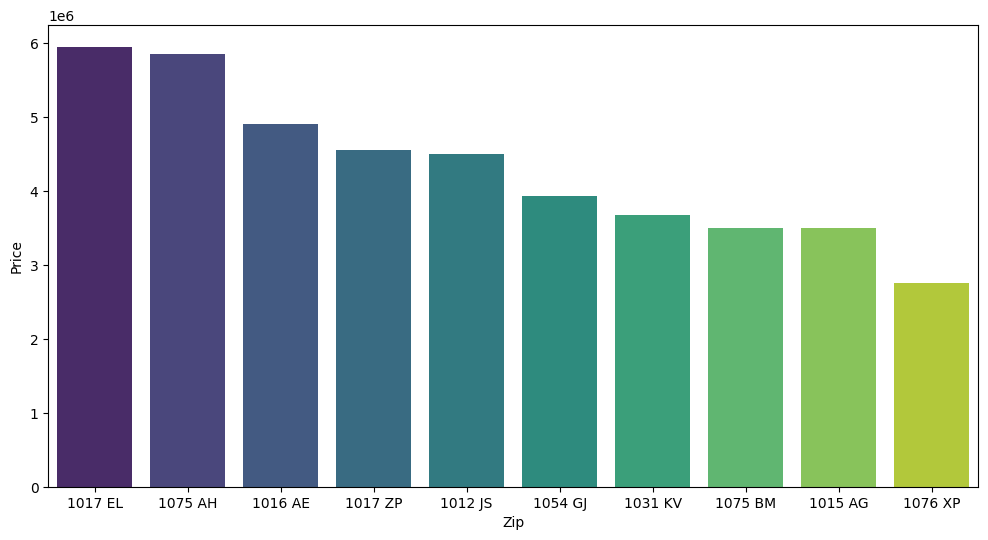

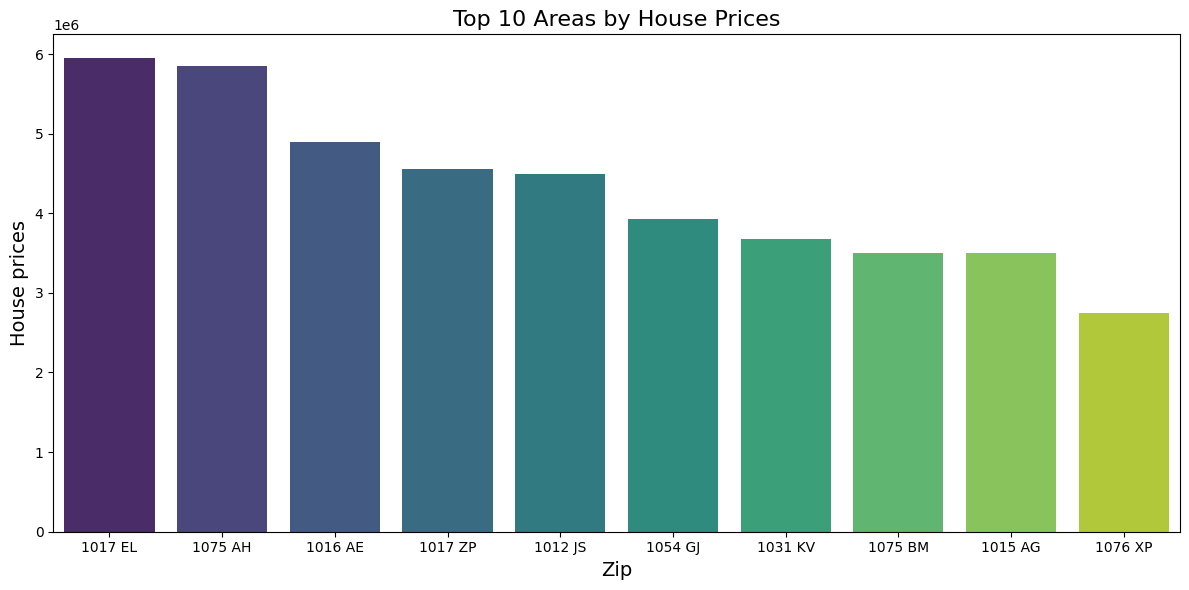

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# case 1: basic
plt.figure(figsize= (12,6))
data_price = houseprices_data.nlargest(10, 'Price')
sns.barplot(data=data_price, x='Zip', y='Price',hue='Zip',  palette="viridis")
plt.show()

# case 2: advanced
plt.figure(figsize=(12,6))
ax = sns.barplot(data=data_price, x='Zip', y='Price',hue='Zip',  palette="viridis")
ax.set_title("Top 10 Areas by House Prices", fontsize=16)
ax.set_xlabel("Zip", fontsize=14)
ax.set_ylabel("House prices", fontsize=14)
plt.tight_layout()
plt.show()


## 1.2.2. Bài tập thực hành 1
+ Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về phân loại chất lượng rượu đỏ. Dữ liệu lấy tại
https://www.kaggle.com/code/eisgandar/red-wine-quality-eda-classification

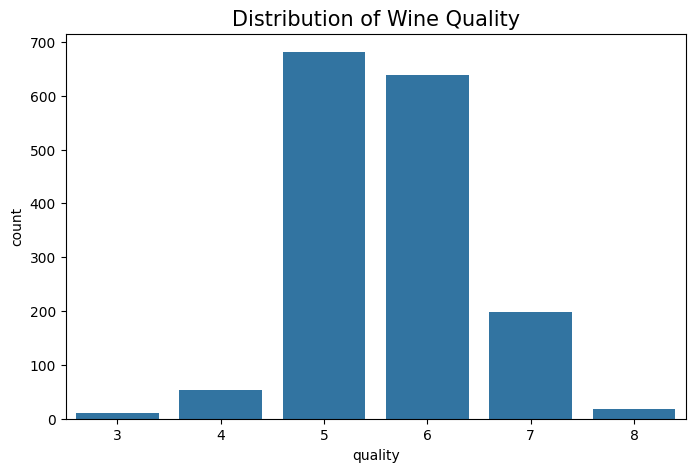

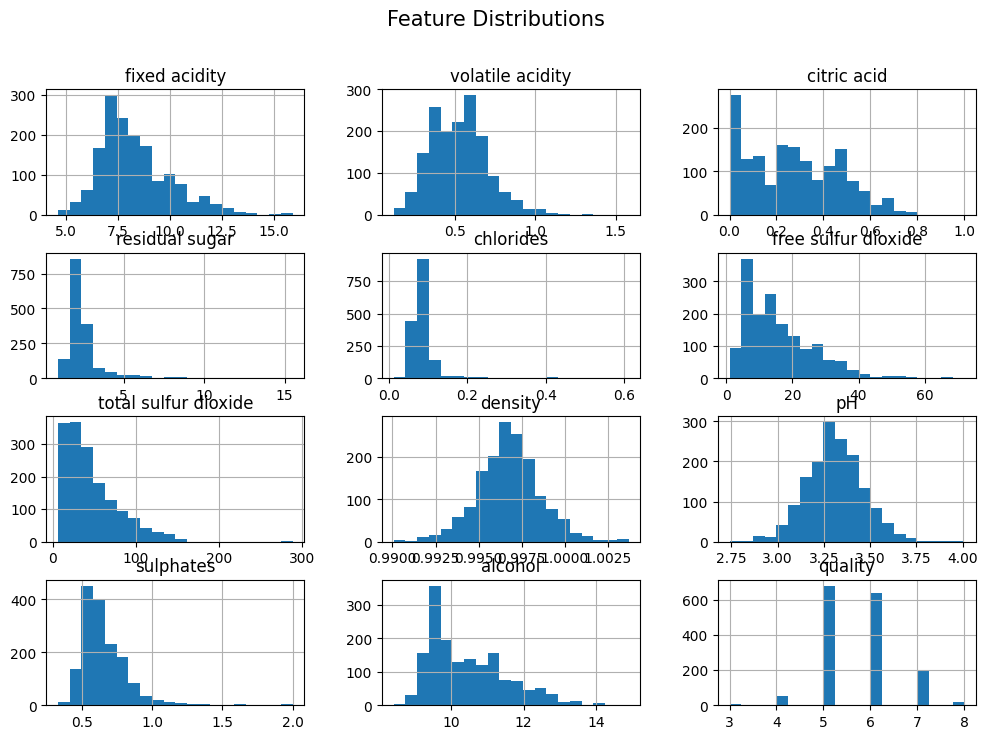

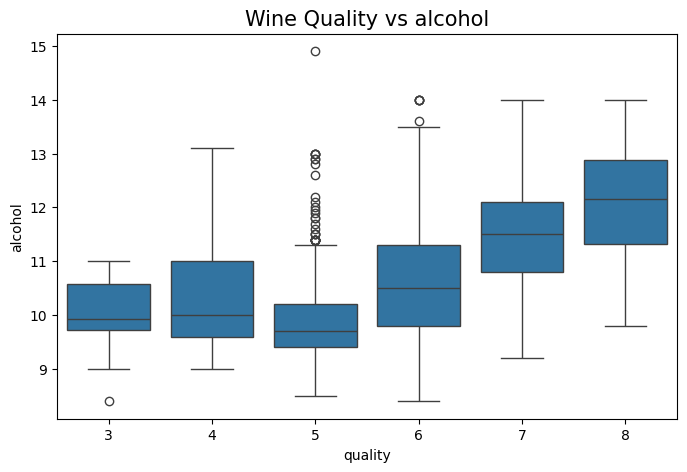

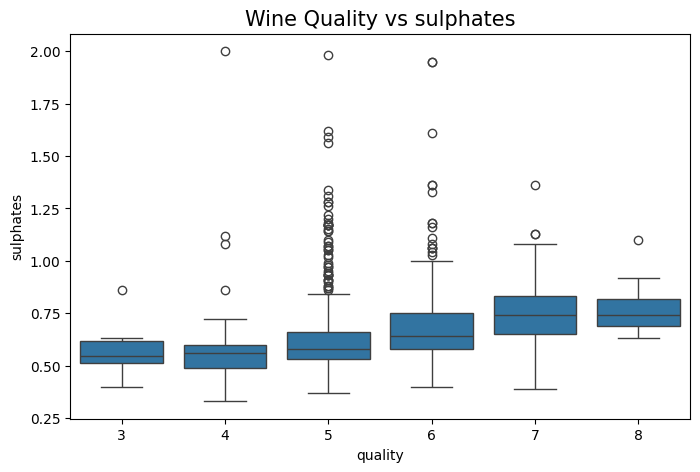

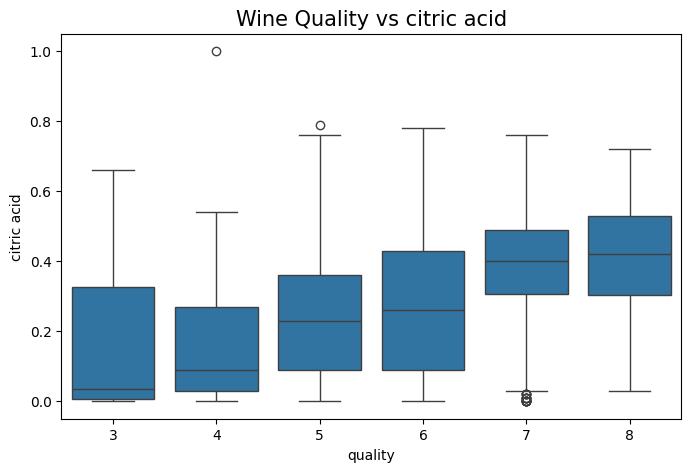

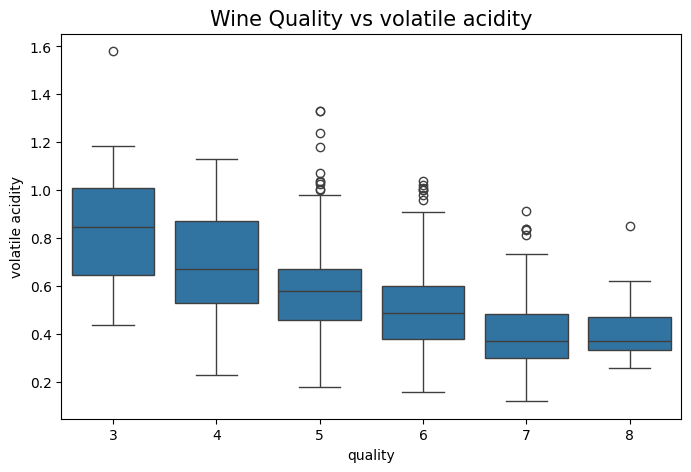

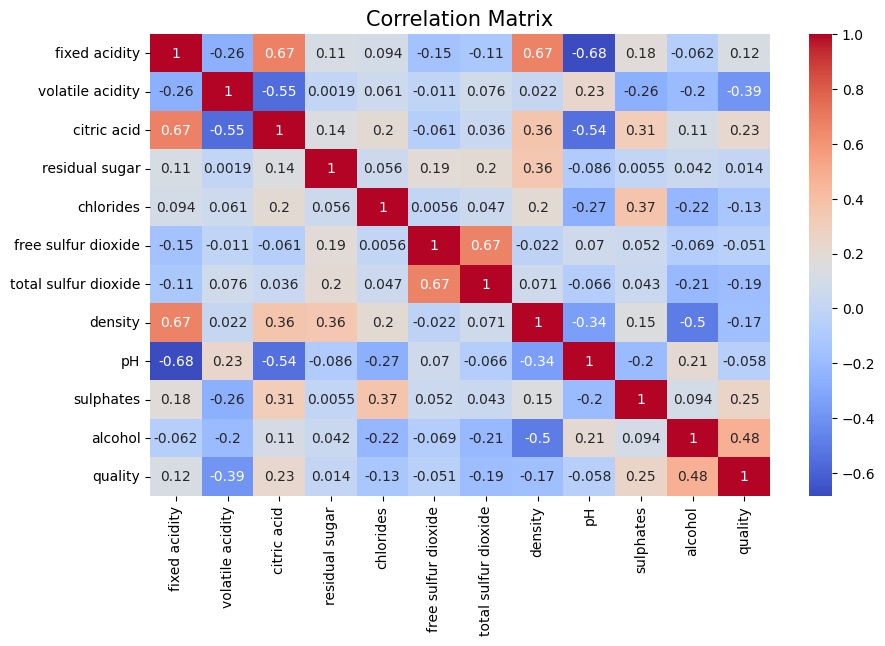

In [ ]:
# --- 1. Basic info ---
# print(wine.head())
# print(wine.info())
# print(wine.describe())
# print("Missing values:\n", wine.isnull().sum())
# print("Duplicate rows:", wine.duplicated().sum())

# --- 2. Target distribution ---
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=wine)
plt.title("Distribution of Wine Quality", fontsize=15)
plt.show()

# --- 3. Feature distributions ---
wine.hist(figsize=(12,8), bins=20)
plt.suptitle("Feature Distributions", fontsize=15)
plt.show()

# --- 4. Boxplot: quality vs key features ---
key_features = ['alcohol', 'sulphates', 'citric acid', 'volatile acidity']
for col in key_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='quality', y=col, data=wine)
    plt.title(f'Wine Quality vs {col}', fontsize=15)
    plt.show()

# --- 5. Correlation heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(wine.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix", fontsize=15)
plt.show()

## 1.2.3. Bài tập thực hành 2
+ Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về bệnh tiểu đường. Dữ liệu lấy tại
https://www.kaggle.com/code/vincentlugat/pima-indians-diabetes-eda-prediction-0-906


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

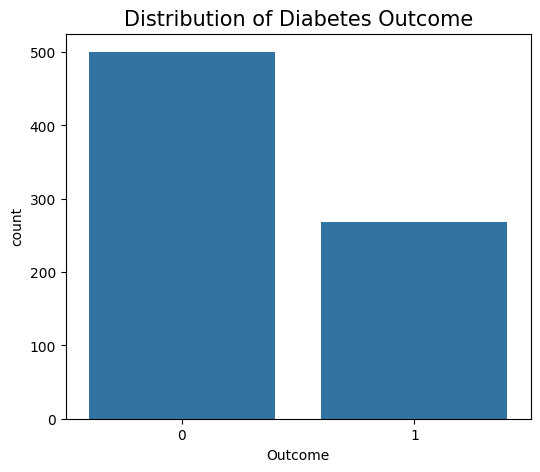

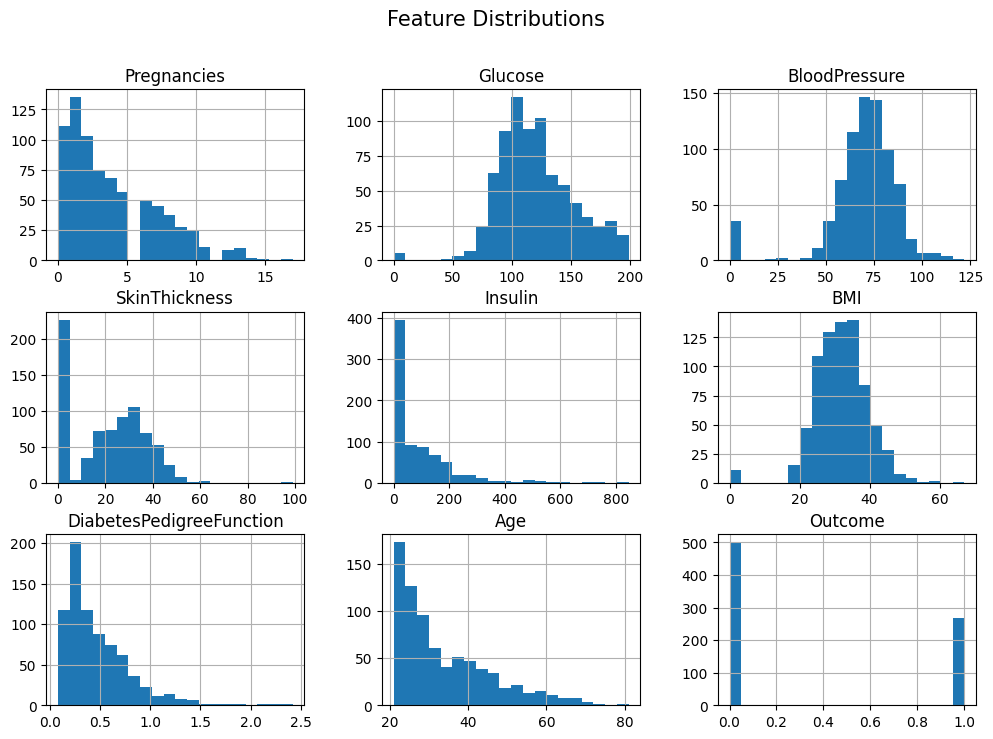

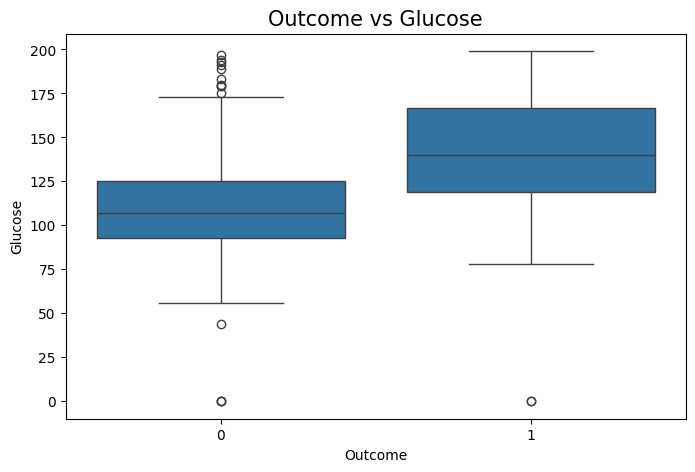

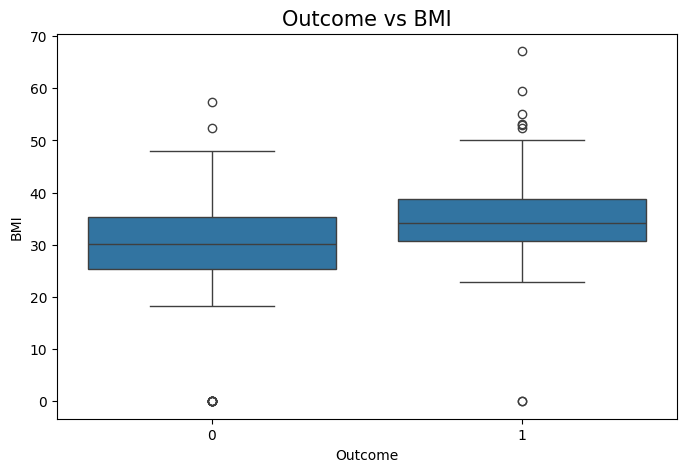

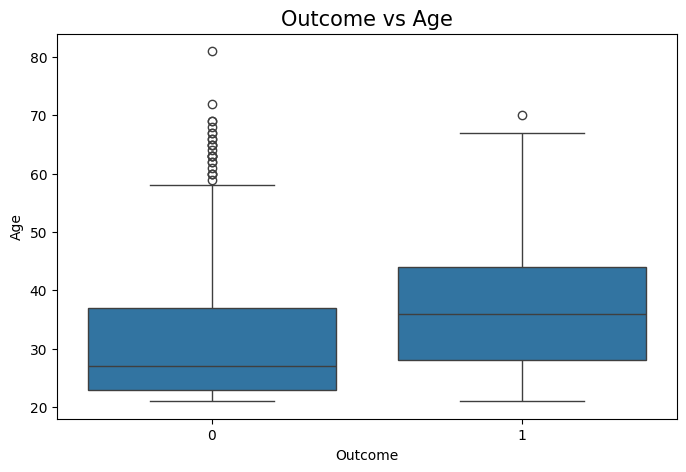

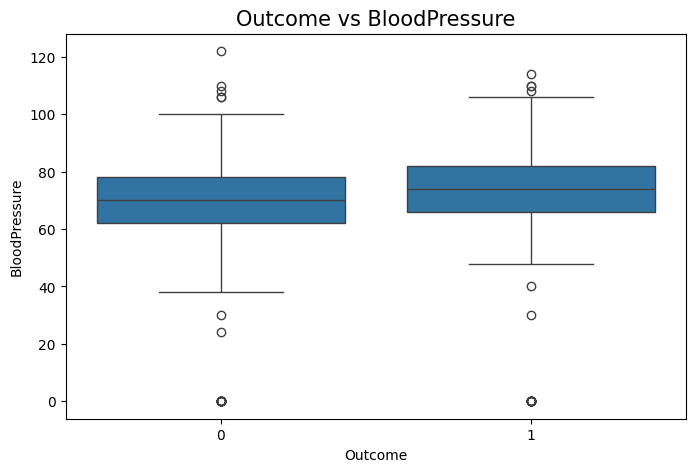

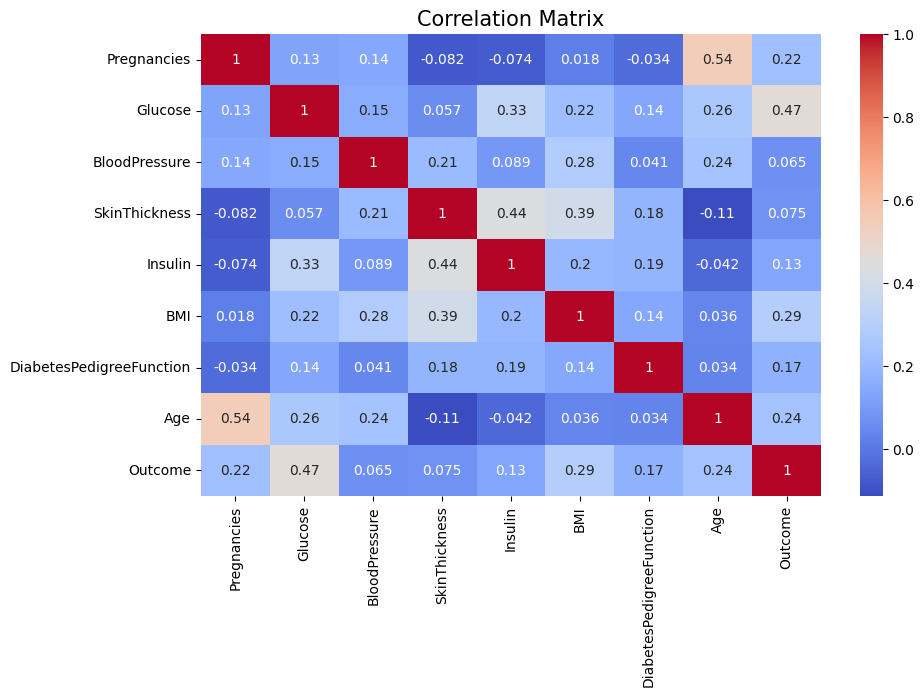

In [ ]:
# ----------------------------
# 2. Diabetes Dataset EDA
# ----------------------------

# --- 1. Basic info ---
#print(diabetes.head())
#print(diabetes.info())
#print(diabetes.describe())
print("Missing values:\n", diabetes.isnull().sum())
print("Duplicate rows:", diabetes.duplicated().sum())

# --- 2. Target distribution ---
plt.figure(figsize=(6,5))
sns.countplot(x='Outcome', data=diabetes)
plt.title("Distribution of Diabetes Outcome", fontsize=15)
plt.show()

# --- 3. Feature distributions ---
diabetes.hist(figsize=(12,8), bins=20)
plt.suptitle("Feature Distributions", fontsize=15)
plt.show()

# --- 4. Boxplot: Outcome vs key features ---
key_features = ['Glucose', 'BMI', 'Age', 'BloodPressure']
for col in key_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Outcome', y=col, data=diabetes)
    plt.title(f'Outcome vs {col}', fontsize=15)
    plt.show()

# --- 5. Correlation heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(diabetes.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix", fontsize=15)
plt.show()

+ Thực hiện EDA trên tập dữ liệu mua sắm tại siêu thị. Tập dữ liệu lấy từ
https://www.kaggle.com/code/rajatkumar30/eda-online-retail

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   

     Month  
0  2010-12  
1  2010-12  
2  2010-12  
3  2010-12  
4  2010-12  
<class 'pandas.core.frame.DataFr

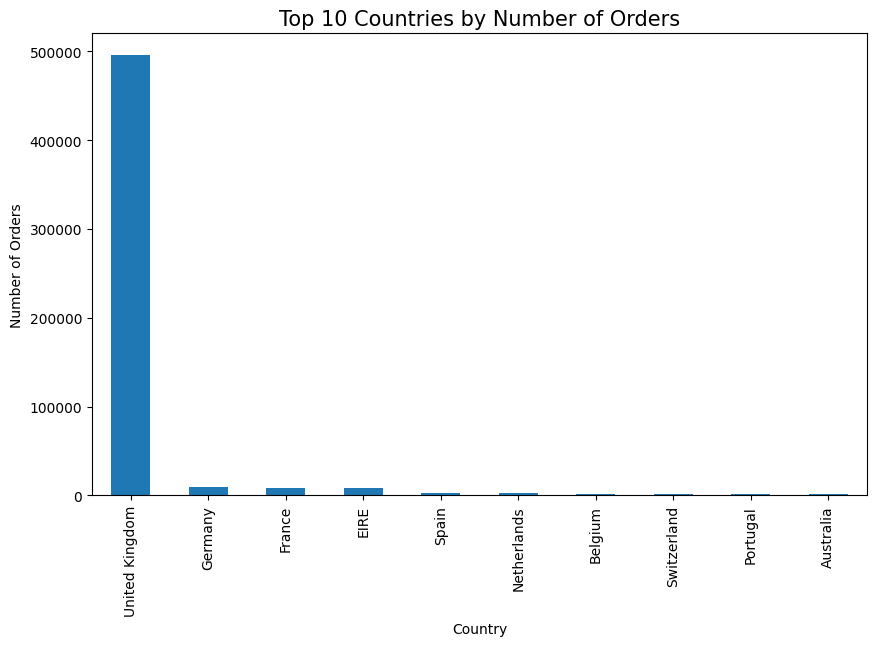

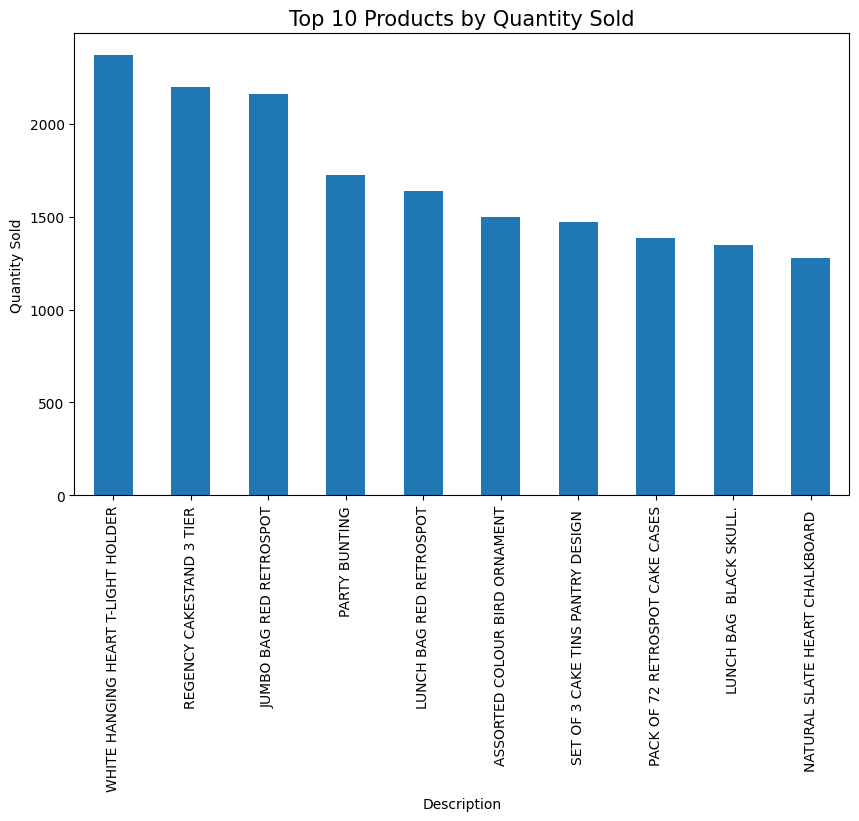

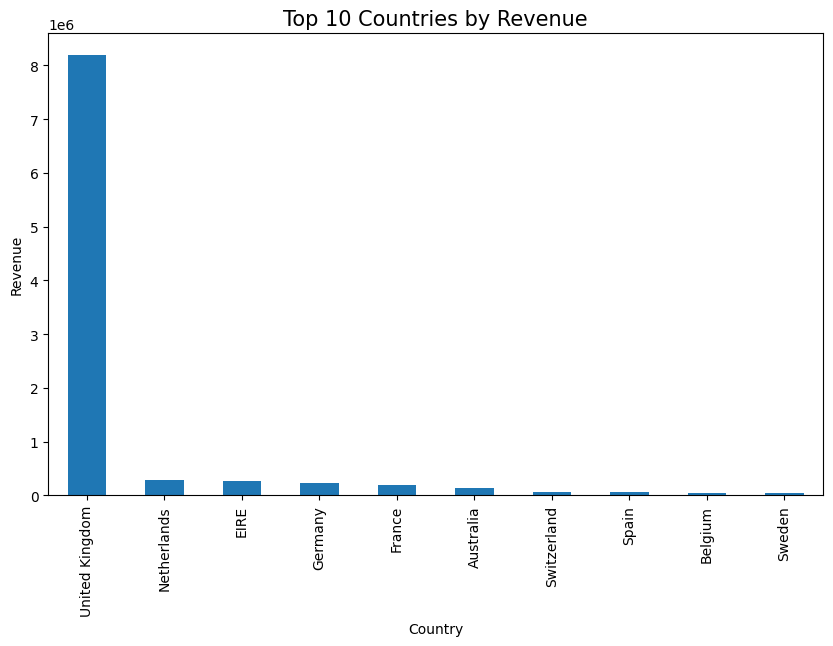

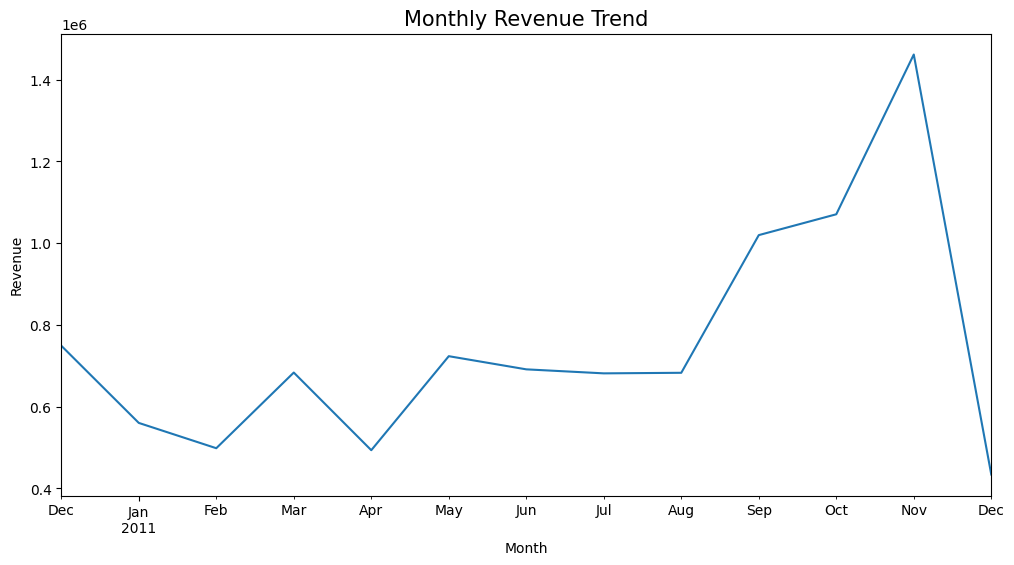

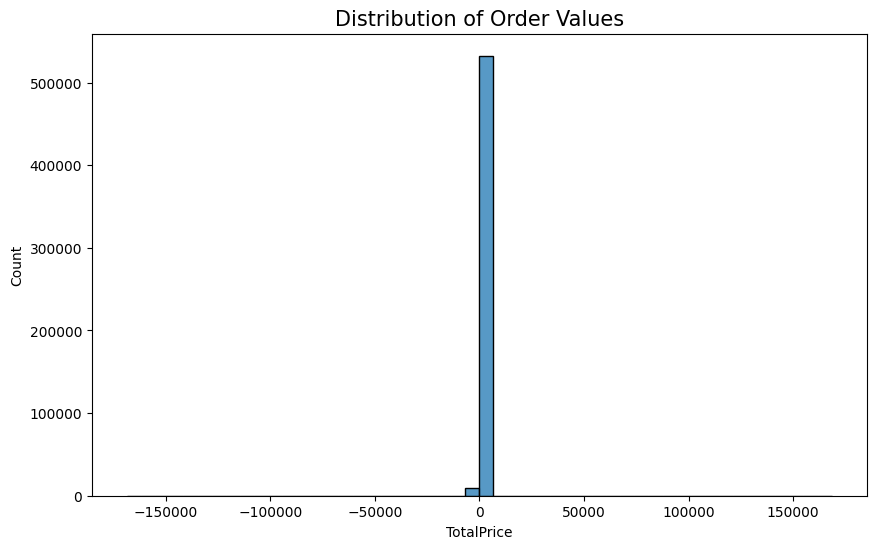

In [ ]:
# ----------------------------
# 3. Online Retail EDA
# ----------------------------
#online_retail = pd.read_excel("Online Retail.xlsx")  # adjust path

# --- 1. Basic info ---
# print(online_retail.head())
# print(online_retail.info())
# print(online_retail.describe().T)
# print("Missing values:\n", online_retail.isnull().sum())
# print("Duplicate rows:", online_retail.duplicated().sum())

# --- 2. Create TotalPrice column ---
online_retail['TotalPrice'] = online_retail['Quantity'] * online_retail['UnitPrice']

# --- 3. Top countries by number of orders ---
top_countries = online_retail['Country'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Number of Orders", fontsize=15)
plt.ylabel("Number of Orders")
plt.show()

# --- 4. Top selling products ---
top_products = online_retail['Description'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold", fontsize=15)
plt.ylabel("Quantity Sold")
plt.show()

# --- 5. Revenue by country ---
revenue_country = online_retail.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
revenue_country.plot(kind='bar')
plt.title("Top 10 Countries by Revenue", fontsize=15)
plt.ylabel("Revenue")
plt.show()

# --- 6. Monthly sales trend ---
online_retail['InvoiceDate'] = pd.to_datetime(online_retail['InvoiceDate'])
online_retail['Month'] = online_retail['InvoiceDate'].dt.to_period('M')
monthly_sales = online_retail.groupby('Month')['TotalPrice'].sum()
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line')
plt.title("Monthly Revenue Trend", fontsize=15)
plt.ylabel("Revenue")
plt.show()

# --- 7. Distribution of order values ---
plt.figure(figsize=(10,6))
sns.histplot(online_retail['TotalPrice'], bins=50, kde=False)
plt.title("Distribution of Order Values", fontsize=15)
plt.xlabel("TotalPrice")
plt.show()

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------

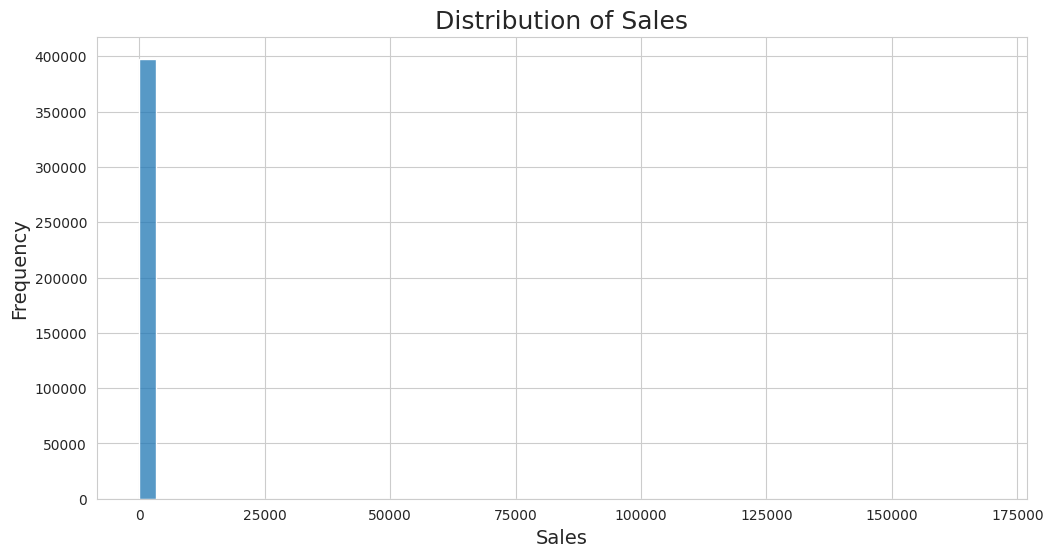

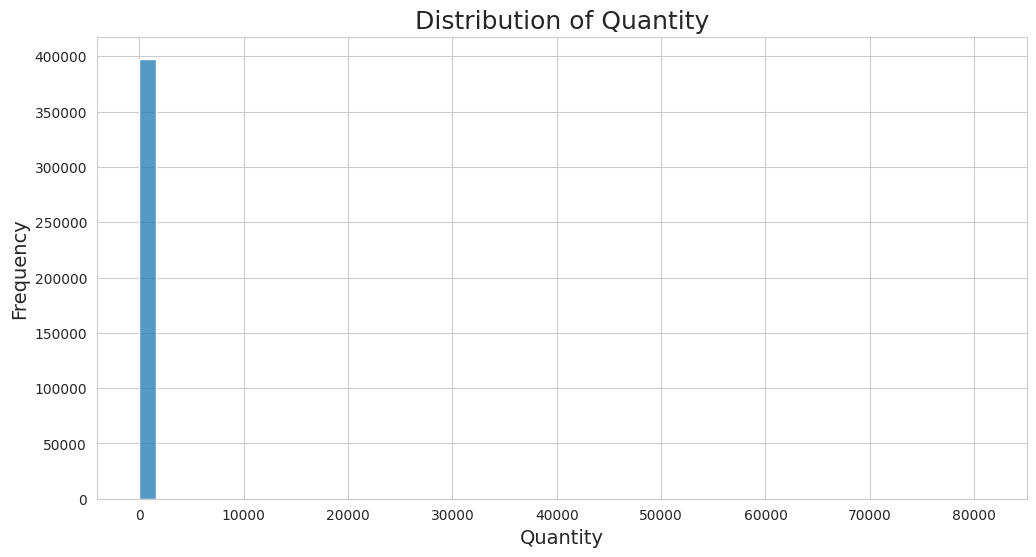

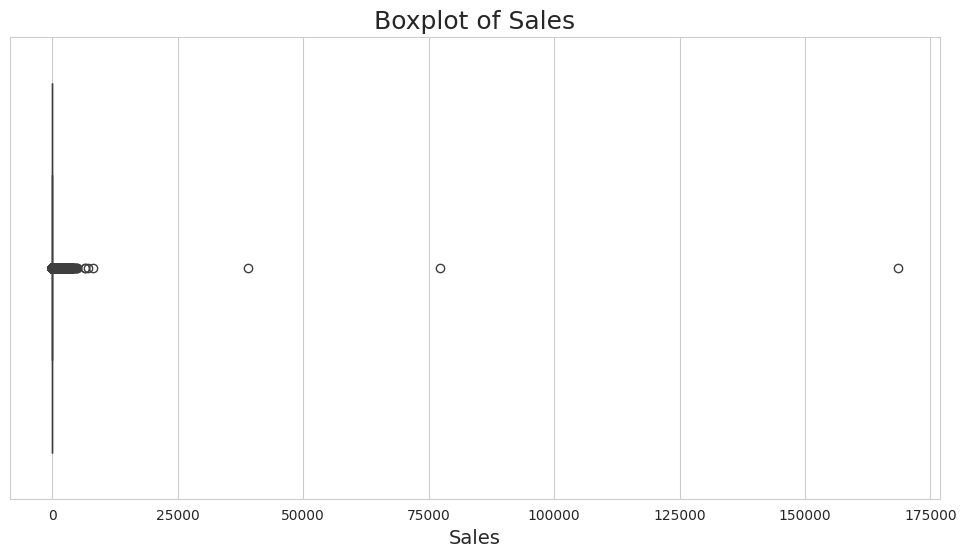

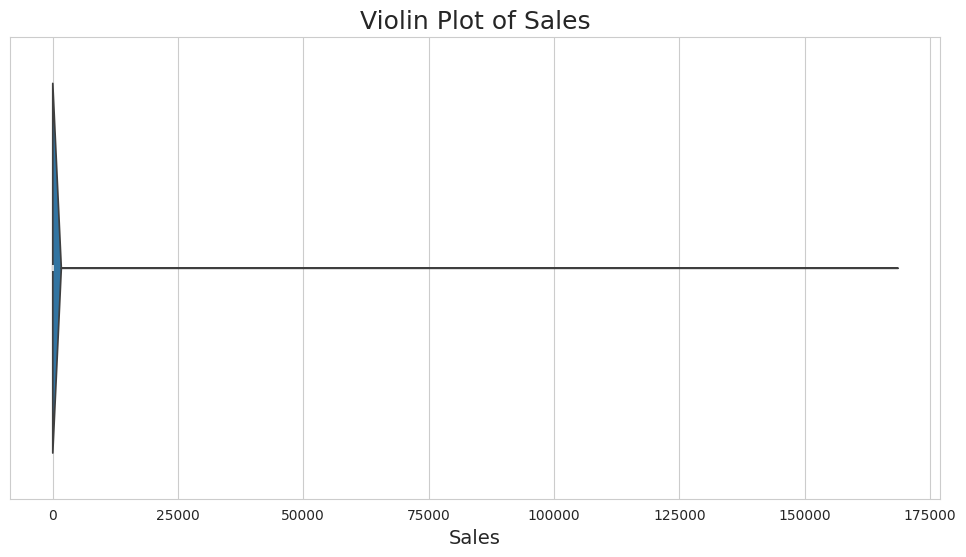

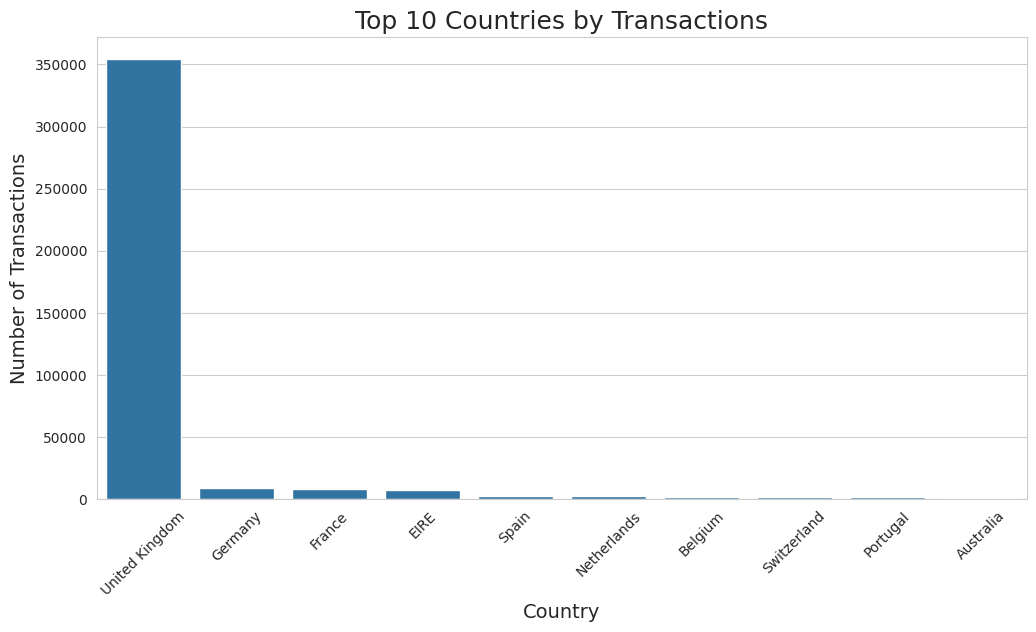

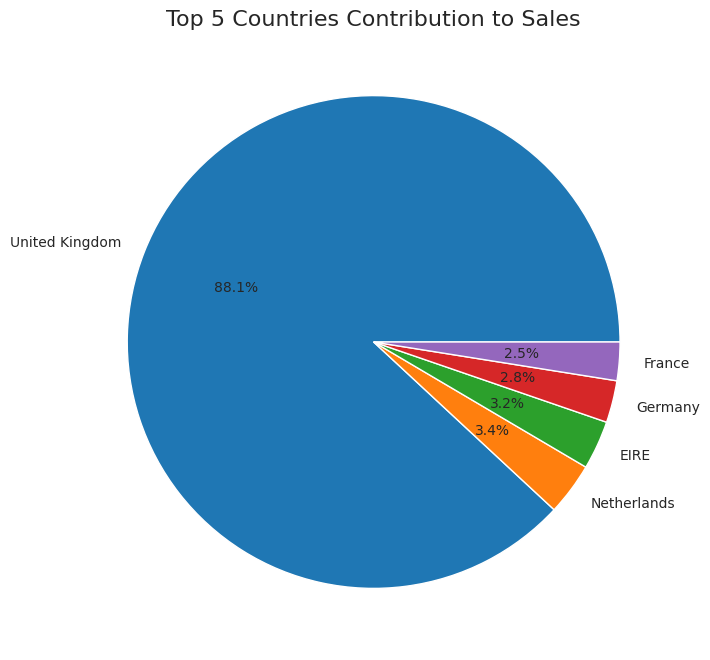

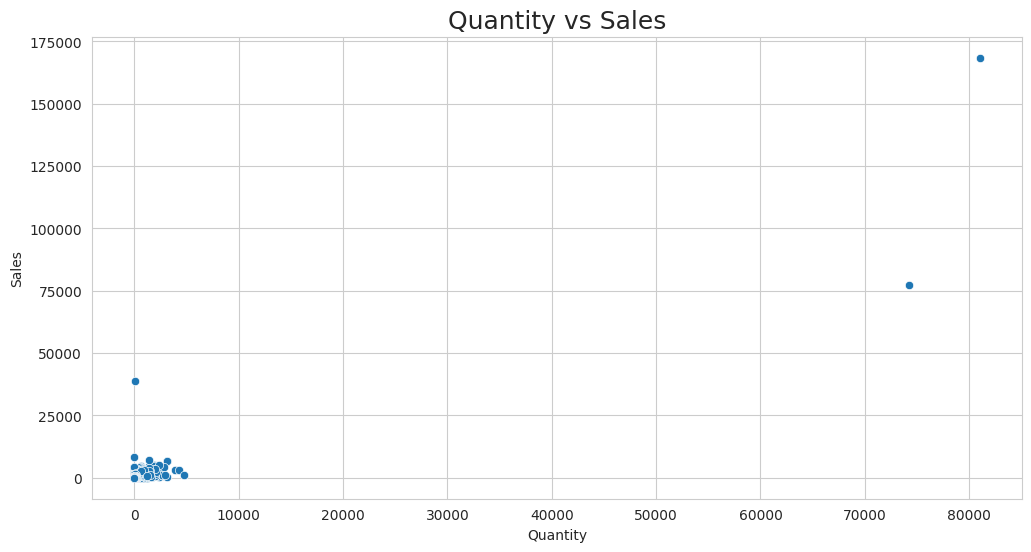


===== CROSSTAB =====
Quantity   False  True 
Country                
Australia    342    840
Austria      214    184
Bahrain       13      4
Belgium     1169    862
Brazil        18     14

===== PIVOT TABLE =====
                  Sales
Country                
Netherlands  121.003111
Australia    117.192310
Japan        116.561900
Singapore     95.852658
Sweden        85.096075
Denmark       49.882474
Lithuania     47.458857
Lebanon       37.641778
EIRE          36.697886
Brazil        35.737500


/tmp/ipykernel_2650/23978624.py:200: FutureWarning:

The provided callable <function mean at 0x7d0565135940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



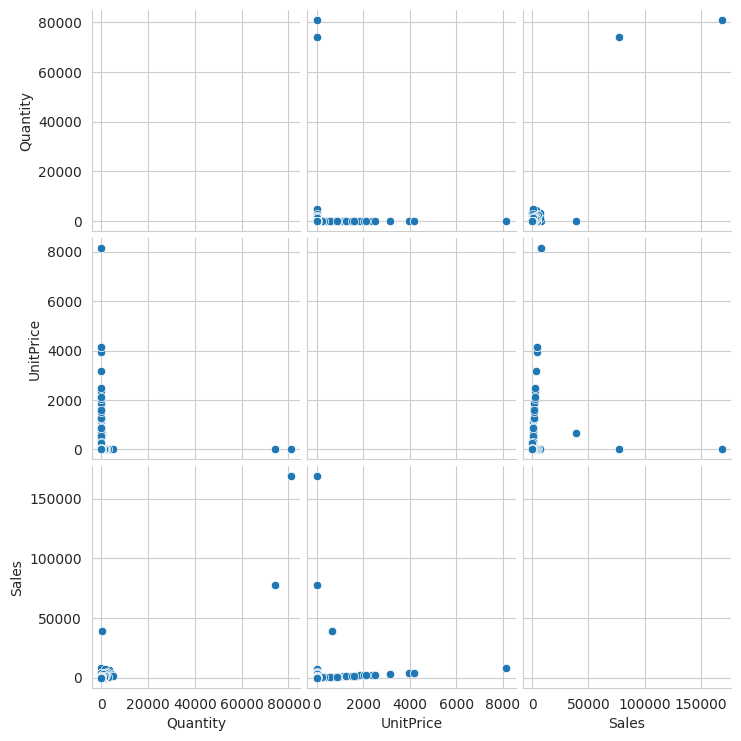

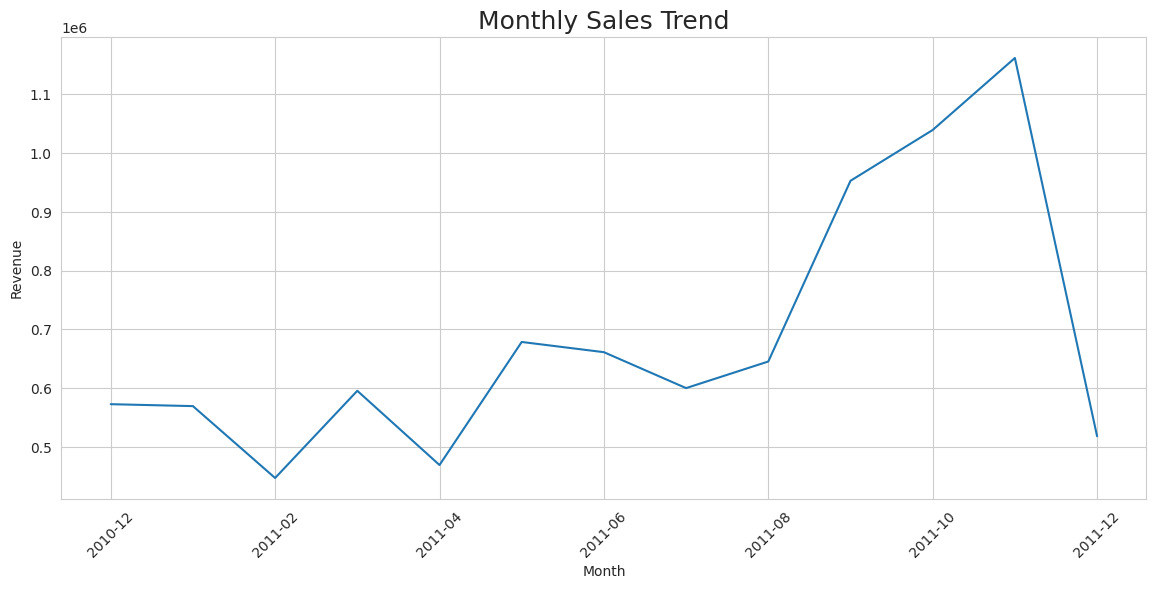

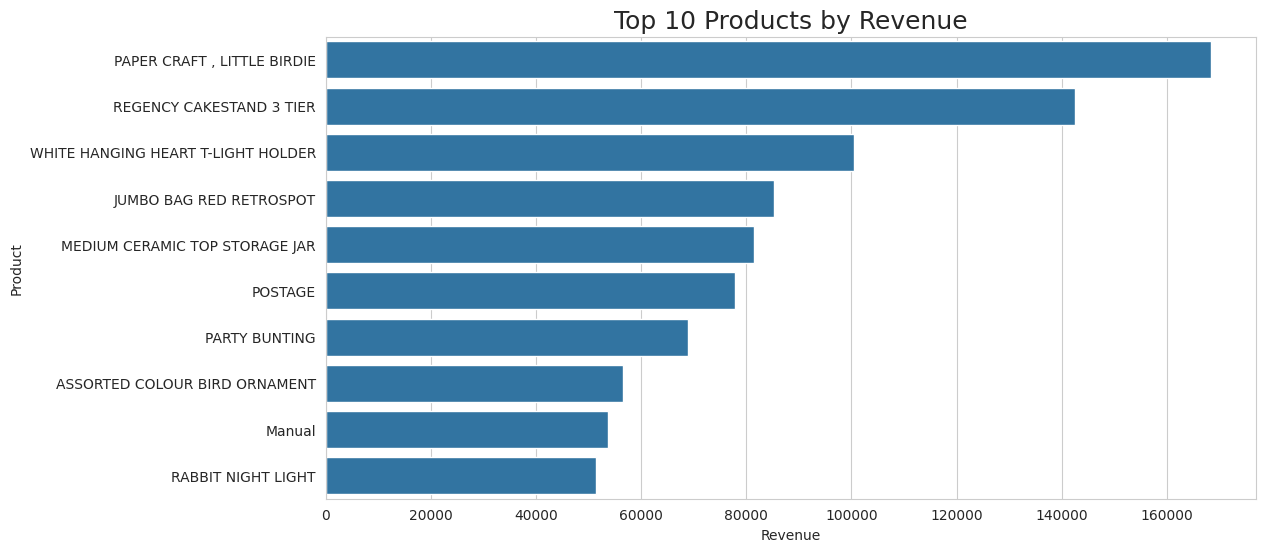


===== CUSTOMER SALES SUMMARY =====
count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: Sales, dtype: float64


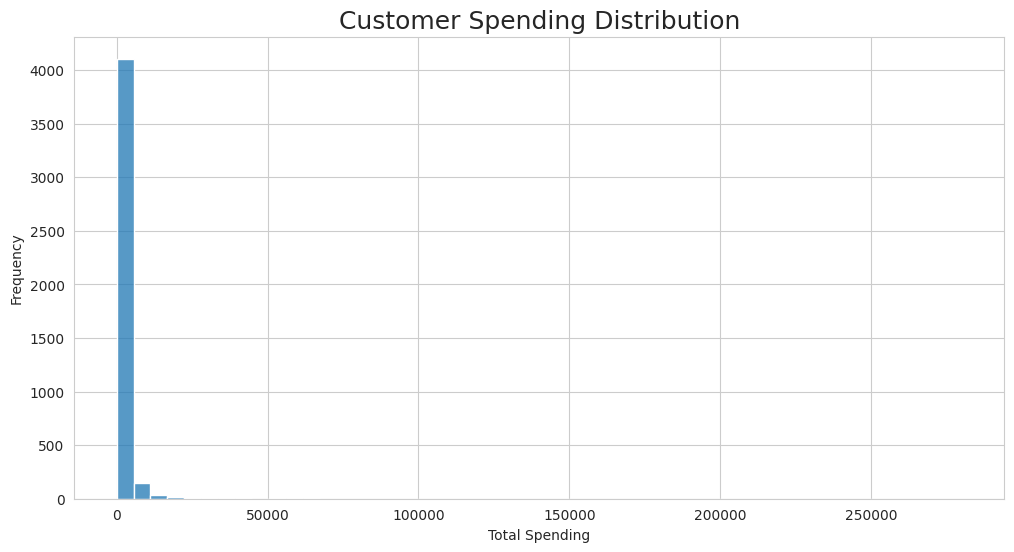

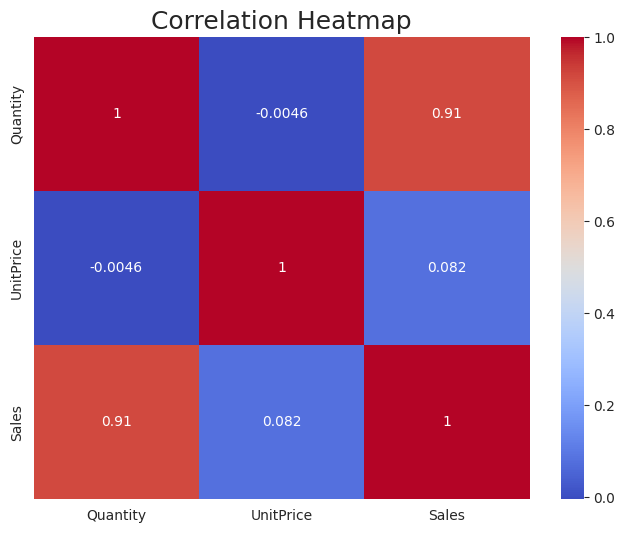


===== TOP 10 CUSTOMERS =====
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Sales, dtype: float64

===== TOP COUNTRIES BY SALES =====
Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Sales, dtype: float64


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:04<00:00,  2.21it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


EDA HTML report generated successfully!

===== CONCLUSION =====

1. Sales distribution is highly right-skewed.
2. Most purchases are small transactions.
3. Some extreme outliers exist in Sales and Quantity.
4. UK contributes the majority of transactions and revenue.
5. Customer spending follows Pareto distribution.
6. Strong positive relationship exists between Quantity and Sales.
7. Seasonal sales trends can be observed over time.



In [ ]:
# =========================================================
# ONLINE RETAIL DATASET - EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================


# Style
sns.set_style("whitegrid")

# =========================
# 2. LOAD DATA
# =========================

# Change file path if needed
df = online_retail

# Display first rows
print(df.head())

# =========================
# 3. BASIC INFORMATION
# =========================

print("\n===== INFO =====")
print(df.info())

print("\n===== DESCRIBE =====")
print(df.describe())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== SHAPE =====")
print(df.shape)

# =========================
# 4. DATA CLEANING
# =========================

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove missing customer IDs
df = df.dropna(subset=['CustomerID'])

# Remove negative quantities
df = df[df['Quantity'] > 0]

# Remove negative prices
df = df[df['UnitPrice'] > 0]

# Create Sales column
df['Sales'] = df['Quantity'] * df['UnitPrice']

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\n===== CLEANED DATA SHAPE =====")
print(df.shape)

# =========================
# 5. UNIVARIATE ANALYSIS
# =========================

# ---------------------------------
# Histogram - Sales
# ---------------------------------

plt.figure(figsize=(12,6))

ax = sns.histplot(df['Sales'], bins=50)

ax.set_title('Distribution of Sales', fontsize=18)
ax.set_xlabel('Sales', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)

plt.show()

# ---------------------------------
# Histogram - Quantity
# ---------------------------------

plt.figure(figsize=(12,6))

ax = sns.histplot(df['Quantity'], bins=50)

ax.set_title('Distribution of Quantity', fontsize=18)
ax.set_xlabel('Quantity', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)

plt.show()

# ---------------------------------
# Boxplot - Sales
# ---------------------------------

plt.figure(figsize=(12,6))

ax = sns.boxplot(x=df['Sales'])

ax.set_title('Boxplot of Sales', fontsize=18)
ax.set_xlabel('Sales', fontsize=14)

plt.show()

# ---------------------------------
# Violin Plot - Sales
# ---------------------------------

plt.figure(figsize=(12,6))

ax = sns.violinplot(x=df['Sales'])

ax.set_title('Violin Plot of Sales', fontsize=18)
ax.set_xlabel('Sales', fontsize=14)

plt.show()

# ---------------------------------
# Countplot / Bar Chart
# Top 10 Countries
# ---------------------------------

top_country = df['Country'].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_country.index,
    y=top_country.values
)

ax.set_title('Top 10 Countries by Transactions', fontsize=18)
ax.set_xlabel('Country', fontsize=14)
ax.set_ylabel('Number of Transactions', fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ---------------------------------
# Pie Chart
# Top 5 Countries by Sales
# ---------------------------------

country_sales = df.groupby('Country')['Sales'].sum() \
                  .sort_values(ascending=False) \
                  .head(5)

plt.figure(figsize=(8,8))

plt.pie(
    country_sales.values,
    labels=country_sales.index,
    autopct='%1.1f%%'
)

plt.title('Top 5 Countries Contribution to Sales', fontsize=16)

plt.show()

# =========================
# 6. BIVARIATE ANALYSIS
# =========================

# ---------------------------------
# Scatterplot
# Quantity vs Sales
# ---------------------------------

plt.figure(figsize=(12,6))

ax = sns.scatterplot(
    data=df,
    x='Quantity',
    y='Sales'
)

ax.set_title('Quantity vs Sales', fontsize=18)

plt.show()

# ---------------------------------
# Crosstab
# Country vs High Quantity Purchase
# ---------------------------------

cross_tab = pd.crosstab(
    df['Country'],
    df['Quantity'] > 10
)

print("\n===== CROSSTAB =====")
print(cross_tab.head())

# ---------------------------------
# Pivot Table
# Average Sales by Country
# ---------------------------------

pivot_country = pd.pivot_table(
    df,
    values='Sales',
    index='Country',
    aggfunc=np.mean
).sort_values(by='Sales', ascending=False)

print("\n===== PIVOT TABLE =====")
print(pivot_country.head(10))

# ---------------------------------
# Pairplot
# ---------------------------------

sns.pairplot(
    df[['Quantity', 'UnitPrice', 'Sales']]
)

plt.show()

# =========================
# 7. TIME SERIES ANALYSIS
# =========================

# Create Month-Year column
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

# Monthly Sales
monthly_sales = df.groupby('MonthYear')['Sales'].sum()

# Convert index to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title('Monthly Sales Trend', fontsize=18)
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

# =========================
# 8. TOP PRODUCTS ANALYSIS
# =========================

top_products = df.groupby('Description')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top 10 Products by Revenue', fontsize=18)
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

# =========================
# 9. CUSTOMER ANALYSIS
# =========================

customer_sales = df.groupby('CustomerID')['Sales'].sum()

print("\n===== CUSTOMER SALES SUMMARY =====")
print(customer_sales.describe())

# Histogram of Customer Spending

plt.figure(figsize=(12,6))

sns.histplot(customer_sales, bins=50)

plt.title('Customer Spending Distribution', fontsize=18)
plt.xlabel('Total Spending')
plt.ylabel('Frequency')

plt.show()

# =========================
# 10. CORRELATION HEATMAP
# =========================

numeric_df = df[['Quantity', 'UnitPrice', 'Sales']]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap', fontsize=18)

plt.show()

# =========================
# 11. ADDITIONAL ANALYSIS
# =========================

# Top 10 customers by revenue

top_customers = df.groupby('CustomerID')['Sales'].sum() \
                  .sort_values(ascending=False) \
                  .head(10)

print("\n===== TOP 10 CUSTOMERS =====")
print(top_customers)

# Top countries by revenue

top_country_sales = df.groupby('Country')['Sales'].sum() \
                      .sort_values(ascending=False) \
                      .head(10)

print("\n===== TOP COUNTRIES BY SALES =====")
print(top_country_sales)

# =========================
# 12. AUTOMATED EDA
# =========================

# Create HTML EDA Report

profile = ProfileReport(
    df,
    title="Online Retail EDA Report",
    explorative=True
)

profile.to_file("online_retail_report.html")

print("\nEDA HTML report generated successfully!")

# =========================
# 13. DTALE (OPTIONAL)
# =========================

# Uncomment if dtale installed

# import dtale
# dtale.show(df).open_browser()


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,397884.0,12.988238,1.0,2.0,6.0,12.0,80995.0,179.331775
InvoiceDate,397884,2011-07-10 23:41:23.511023360,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 14:39:00,2011-10-20 14:33:00,2011-12-09 12:50:00,NaN
UnitPrice,397884.0,3.116488,0.001,1.25,1.95,3.75,8142.75,22.097877
CustomerID,397884.0,15294.423453,12346.0,13969.0,15159.0,16795.0,18287.0,1713.14156
Sales,397884.0,22.397,0.001,4.68,11.8,19.8,168469.6,309.071041


In [ ]:
# Select required columns (as per typical dataset usage)
online_retail = online_retail[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'InvoiceDate', 'UnitPrice',
     'CustomerID', 'Country']
]

# =========================================================
# 3. UNIVARIATE ANALYSIS
# =========================================================

# -------------------------
# 3.1 HISTOGRAM (Quantity)
# -------------------------

sns.histplot(data=online_retail, x=online_retail["Quantity"])

plt.figure(figsize=(12,6))
ax = sns.histplot(data=online_retail, x=online_retail["Quantity"])
ax.set_xlabel("Quantity", fontsize=15)
ax.set_ylabel("Count of records", fontsize=15)
ax.set_title("Univariate Analysis of Quantity", fontsize=20)
plt.show()


# -------------------------
# 3.2 COUNT PLOT (Country)
# -------------------------

sns.countplot(data=online_retail, x=online_retail["Country"])

plt.figure(figsize=(12,6))
ax = sns.countplot(data=online_retail, x=online_retail["Country"])
ax.set_xlabel("Country", fontsize=15)
ax.set_ylabel("Count of records", fontsize=15)
ax.set_title("Univariate Analysis of Country", fontsize=20)
plt.xticks(rotation=90)
plt.show()


# -------------------------
# 3.3 PIE CHART (Country)
# -------------------------

country_group = online_retail.groupby("Country").count().reset_index()

plt.figure(figsize=(8,8))

plt.pie(
    country_group["InvoiceNo"],
    labels=country_group["Country"]
)

plt.title("Univariate Analysis of Country", fontsize=15)
plt.show()


# -------------------------
# 3.4 BOXPLOT (UnitPrice)
# -------------------------

sns.boxplot(data=online_retail, x=online_retail["UnitPrice"])

plt.figure(figsize=(12,6))
ax = sns.boxplot(data=online_retail, x=online_retail["UnitPrice"])
ax.set_xlabel("Unit Price", fontsize=15)
ax.set_title("Univariate Analysis of Unit Price", fontsize=20)
plt.ticklabel_format(style='plain', axis='x')
plt.show()


# -------------------------
# 3.5 VIOLIN PLOT (UnitPrice)
# -------------------------

sns.violinplot(data=online_retail, x=online_retail["UnitPrice"])

plt.figure(figsize=(12,6))
ax = sns.violinplot(data=online_retail, x=online_retail["UnitPrice"])
ax.set_xlabel("Unit Price", fontsize=15)
ax.set_title("Univariate Analysis of Unit Price", fontsize=20)
plt.ticklabel_format(style='plain', axis='x')
plt.show()


# -------------------------
# 3.6 DESCRIBE STATISTICS
# -------------------------

online_retail.describe()


# =========================================================
# 4. BIVARIATE ANALYSIS
# =========================================================

# -------------------------
# 4.1 SCATTERPLOT
# -------------------------

sns.scatterplot(
    data=online_retail,
    x=online_retail["Quantity"],
    y=online_retail["UnitPrice"]
)

plt.figure(figsize=(12,6))
ax = sns.scatterplot(
    data=online_retail,
    x=online_retail["Quantity"],
    y=online_retail["UnitPrice"]
)
ax.set_title("Bivariate Analysis of Quantity and Unit Price", fontsize=20)
plt.show()


# -------------------------
# 4.2 CROSSTAB
# -------------------------

pd.crosstab(
    index=online_retail["Country"],
    columns=online_retail["StockCode"]
)


# -------------------------
# 4.3 PIVOT TABLE
# -------------------------

import numpy as np

pd.pivot_table(
    online_retail,
    values="UnitPrice",
    index="Country",
    aggfunc=np.mean
)


# -------------------------
# 4.4 PAIRPLOT
# -------------------------

sns.pairplot(
    data=online_retail[["Quantity", "UnitPrice"]]
)


# =========================================================
# 5. AUTOMATED EDA (TEACHER REQUIRED)
# =========================================================

from ydata_profiling import ProfileReport

profile = ProfileReport(online_retail)

profile.to_file("online_retail_report.html")


# =========================================================
# 6. DTALE (OPTIONAL BUT IN LECTURE)
# =========================================================

# import dtale

# dtale.show(online_retail).open_browser()

# 1.3 PHÂN TÍCH ĐƠN BIẾN VÀ HAI BIẾN

## 1.3.1 Ôn lý thuyết

**Q1: Phân tích đơn biến (univariate analysis) là gì? Nó khác gì với phân tích hai biến (bivariate analysis) trong khám phá dữ liệu?**  
A1:  
- **Phân tích đơn biến (Univariate Analysis)**: Phân tích và tóm tắt một biến dữ liệu, tập trung vào phân bố, trung vị, trung bình, độ lệch chuẩn, min, max, outlier.  
- **Phân tích hai biến (Bivariate Analysis)**: Nghiên cứu mối quan hệ giữa hai biến, xác định xu hướng, tương quan, hoặc quan hệ nhân quả.

---

**Q2: Các thước đo thống kê nào thường được sử dụng trong phân tích đơn biến (ví dụ: trung bình, trung vị, mode, độ lệch chuẩn)?**  
A2:  
- Trung bình (Mean)  
- Trung vị (Median)  
- Mode (giá trị xuất hiện nhiều nhất)  
- Độ lệch chuẩn (Standard Deviation)  
- Phương sai (Variance)  
- Min, Max, Range  
- Các phân vị (Q1, Q3, IQR)  

---

**Q3: Trong phân tích hai biến, làm thế nào để xác định mối quan hệ giữa hai biến (ví dụ: tương quan, nhân quả)?**  
A3:  
- **Tương quan (Correlation)**: Xem hai biến thay đổi cùng nhau như thế nào (dương, âm, hoặc không liên quan).  
- **Hiệp biến (Covariance)**: Đo mức độ thay đổi đồng thời giữa hai biến, chưa chuẩn hóa.  
- **Nhân quả (Causation)**: Thường cần phân tích nâng cao (hồi quy, thí nghiệm, kiểm soát biến).  
- Trực quan hóa: scatter plot, line plot, heatmap để nhận dạng mẫu và tương quan.

---

**Q4: Sự khác biệt giữa tương quan (correlation) và hiệp biến (covariance) trong phân tích hai biến là gì?**  
A4:  
- **Covariance**: Cho biết hướng biến đổi chung (dương/âm) nhưng không chuẩn hóa, giá trị phụ thuộc đơn vị dữ liệu.  
- **Correlation**: Chuẩn hóa covariance, nằm trong [-1, 1], dễ so sánh giữa các cặp biến.

---

**Q5: Khi nào nên sử dụng biểu đồ trực quan hóa trong phân tích đơn biến so với phân tích hai biến?**  
A5:  
- **Đơn biến**: Histogram, boxplot, bar chart, pie chart, dùng để quan sát phân bố, outlier, giá trị trung tâm.  
- **Hai biến**: Scatter plot, line plot, heatmap, boxplot/violin plot, dùng để quan sát mối quan hệ, tương quan hoặc sự khác biệt giữa nhóm.

---

**Q6: Làm thế nào để trực quan hóa mối quan hệ giữa một biến số và một biến phân loại bằng biểu đồ boxplot hoặc violin plot trong Python?**  
A6: Dùng **boxplot** hoặc **violin plot** để so sánh phân bố của biến số theo từng nhóm phân loại.  
- Biểu đồ hiển thị trung vị, tứ phân vị, outlier.  
- Violin plot bổ sung thông tin về mật độ dữ liệu trong từng nhóm.

---

**Q7: Đoạn code mẫu để tạo biểu đồ scatter plot hoặc heatmap để phân tích mối quan hệ giữa hai biến?**  
A7: Trực quan hóa bằng **scatter plot** để xem mối tương quan giữa hai biến số, **heatmap** để xem ma trận tương quan giữa nhiều biến. (Chi tiết code không yêu cầu ở đây)

## 1.3.3. Bài tập thực hành 1
Tìm hiểu các tính năng và cách sử dụng sản phẩm SweetViz (https://pypi.org/project/sweetviz) áp dụng
trên tập dữ liệu Marketing Campaign

In [ ]:
import sweetviz as sv

marketing_report = sv.analyze(marketing)
marketing_report.show_html() # Default arguments will generate to "SWEETVIZ_REPORT.html"

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## 1.3.4. Bài tập thực hành 2
Tìm hiểu các tính năng và cách sử dụng sản phẩm AutoViz (https://pypi.org/project/autoviz) áp dụng trên
tập dữ liệu Marketing Campaign

Shape of your Data Set loaded: (2240, 1)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  0
    Number of Integer-Categorical Columns =  0
    Number of String-Categorical Columns =  0
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  1
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    1 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
To fix these data quality issues in the dataset, import FixDQ from autoviz...
    All variables

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
ID Year_Birth Education Marital_Status Income Kidhome Teenhome Dt_Customer Recency MntWines MntFruits MntMeatProducts MntFishProducts MntSweetProducts MntGoldProds NumDealsPurchases NumWebPurchases NumCatalogPurchases NumStorePurchases NumWebVisitsMonth AcceptedCmp3 AcceptedCmp4 AcceptedCmp5 AcceptedCmp1 AcceptedCmp2 Complain Z_CostContact Z_Revenue Response,object,0.000000,100,,,No issue


No categorical or boolean vars in data set. Hence no pivot plots...
Could not draw wordcloud plot for ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	MntFruits	MntMeatProducts	MntFishProducts	MntSweetProducts	MntGoldProds	NumDealsPurchases	NumWebPurchases	NumCatalogPurchases	NumStorePurchases	NumWebVisitsMonth	AcceptedCmp3	AcceptedCmp4	AcceptedCmp5	AcceptedCmp1	AcceptedCmp2	Complain	Z_CostContact	Z_Revenue	Response. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

All Plots done
Time to run AutoViz = 0 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Package names is already up-to-date!
[nltk_data]    | Do

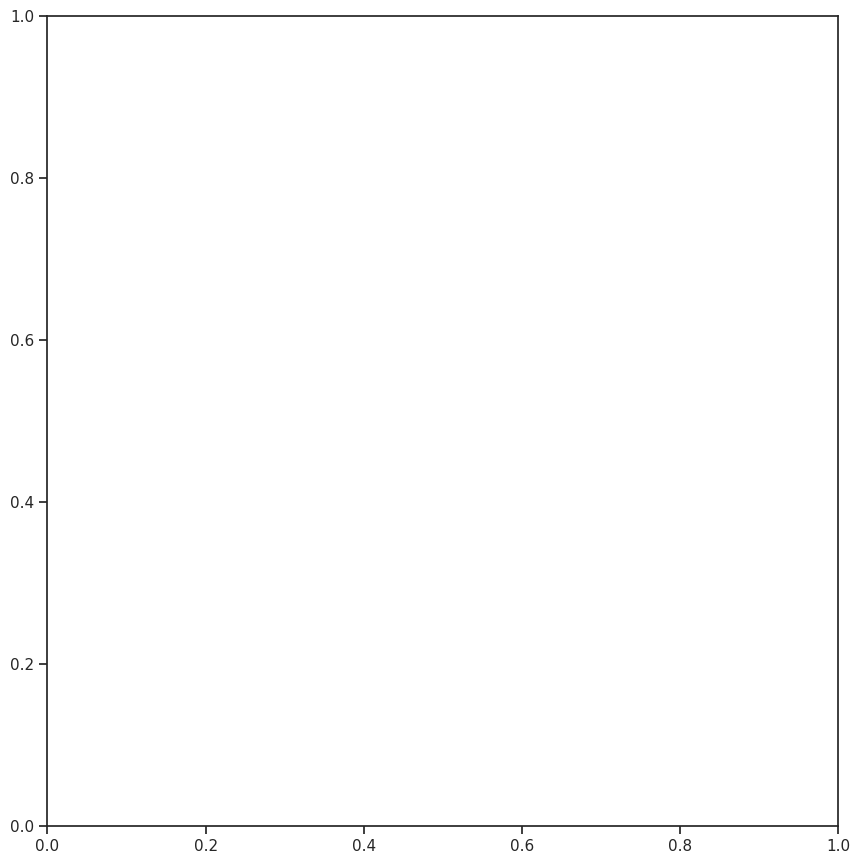

In [ ]:
from autoviz import AutoViz_Class

AV = AutoViz_Class()
dft = AV.AutoViz(
    "",                 # filename placeholder
    sep=",",
    depVar="",
    dfte=marketing,
    header=0,
    verbose=1,
    lowess=False,
    chart_format="svg",
    max_rows_analyzed=150000,
    max_cols_analyzed=30,
    save_plot_dir=None
)